# Elliptic Bitcoin Dataset — Model Training
## XGBoost (fast inference) + GraphSAGE (graph-aware accuracy)

**Split strategy:** time-based (same as original paper)
- Train: time steps 1–34
- Test:  time steps 35–49

Only **labeled** transactions (class 1 or 2) are used for supervised training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/vighaneshs/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1/elliptic_bitcoin_dataset/'

feat_cols = ['txId', 'time_step'] + [f'local_feat_{i}' for i in range(1, 94)] + [f'agg_feat_{i}' for i in range(1, 73)]
df_feat    = pd.read_csv(DATA_DIR + 'elliptic_txs_features.csv', header=None, names=feat_cols)
df_classes = pd.read_csv(DATA_DIR + 'elliptic_txs_classes.csv')
df_edges   = pd.read_csv(DATA_DIR + 'elliptic_txs_edgelist.csv')

df = df_feat.merge(df_classes, on='txId', how='left')
df['label'] = df['class'].astype(str).map({'1': 'illicit', '2': 'licit'}).fillna('unknown')
df['y'] = df['class'].astype(str).map({'1': 1, '2': 0}).fillna(-1).astype(int)

feat_only = [c for c in df.columns if c.startswith('local_feat') or c.startswith('agg_feat')]
print(f'Loaded {len(df):,} transactions, {len(df_edges):,} edges')

Loaded 203,769 transactions, 234,355 edges


## 1. Time-based Train/Test Split

In [2]:
labeled = df[df['y'] != -1].copy()

train_df = labeled[labeled['time_step'] <= 34]
test_df  = labeled[labeled['time_step'] >  34]

X_train, y_train = train_df[feat_only].values, train_df['y'].values
X_test,  y_test  = test_df[feat_only].values,  test_df['y'].values

print(f'Train: {len(X_train):,}  (illicit={y_train.sum():,}, licit={(y_train==0).sum():,})')
print(f'Test:  {len(X_test):,}   (illicit={y_test.sum():,},  licit={(y_test==0).sum():,})')

# Class weight for imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train: 29,894  (illicit=3,462, licit=26,432)
Test:  16,670   (illicit=1,083,  licit=15,587)
scale_pos_weight: 7.63


## 2. XGBoost

In [3]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import time

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',       # fast histogram method
    device='cpu',
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)

t0 = time.time()
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
train_time = time.time() - t0
print(f'Training time: {train_time:.1f}s')

Training time: 1.6s


In [4]:
t0 = time.time()
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_infer_time = (time.time() - t0) * 1000

print('=== XGBoost Results ===')
print(f'Inference time: {xgb_infer_time:.1f}ms for {len(X_test):,} transactions ({xgb_infer_time/len(X_test)*1000:.2f}µs/tx)')
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['licit','illicit']))

=== XGBoost Results ===
Inference time: 18.4ms for 16,670 transactions (1.10µs/tx)
ROC-AUC: 0.9344

              precision    recall  f1-score   support

       licit       0.98      0.99      0.99     15587
     illicit       0.81      0.74      0.77      1083

    accuracy                           0.97     16670
   macro avg       0.90      0.86      0.88     16670
weighted avg       0.97      0.97      0.97     16670



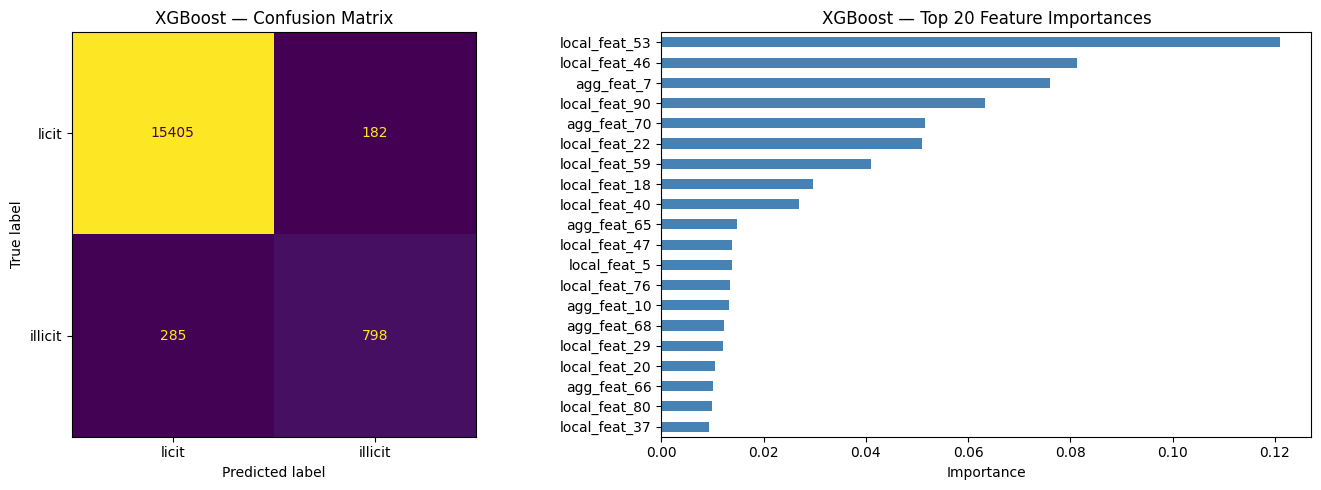

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm, display_labels=['licit','illicit']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('XGBoost — Confusion Matrix')

# Feature importance (top 20)
importance = pd.Series(xgb_model.feature_importances_, index=feat_only).sort_values(ascending=False).head(20)
importance.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('XGBoost — Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 3. GraphSAGE

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Build node index mapping
all_tx = df['txId'].values
tx_to_idx = {tx: i for i, tx in enumerate(all_tx)}
N = len(all_tx)

# Node features
x = torch.tensor(df[feat_only].values, dtype=torch.float)

# Labels (-1 for unknown)
y_all = torch.tensor(df['y'].values, dtype=torch.long)

# Edge index
src = df_edges['txId1'].map(tx_to_idx).dropna().astype(int)
dst = df_edges['txId2'].map(tx_to_idx).dropna().astype(int)
valid = src.notna() & dst.notna()
edge_index = torch.tensor(
    np.stack([src.values, dst.values], axis=0), dtype=torch.long)

# Train/test masks (labeled only, time-based)
train_mask = torch.tensor(
    (df['y'].values != -1) & (df['time_step'].values <= 34), dtype=torch.bool)
test_mask  = torch.tensor(
    (df['y'].values != -1) & (df['time_step'].values >  34), dtype=torch.bool)

data = Data(x=x, edge_index=edge_index, y=y_all,
            train_mask=train_mask, test_mask=test_mask)
print(data)
print(f'Train nodes: {train_mask.sum()}, Test nodes: {test_mask.sum()}')

Using device: mps


In [ ]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.3, training=self.training)
        return self.convs[-1](x, edge_index)


model = GraphSAGE(in_channels=165, hidden_channels=128, out_channels=2, num_layers=3).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

In [ ]:
# Use NeighborLoader for mini-batch training (efficient on large graphs)
train_loader = NeighborLoader(
    data,
    num_neighbors=[10, 10, 10],
    batch_size=512,
    input_nodes=data.train_mask,
    shuffle=True
)

# Class weights for imbalance
pos_weight = torch.tensor([1.0, scale_pos_weight], dtype=torch.float).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        # Only compute loss on seed nodes (first batch_size nodes)
        seed_nodes = batch.batch_size
        loss = F.cross_entropy(out[:seed_nodes], batch.y[:seed_nodes], weight=pos_weight)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

print('Starting training...')
t0 = time.time()
losses = []
EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch()
    losses.append(loss)
    scheduler.step()
    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}')

sage_train_time = time.time() - t0
print(f'\nTotal training time: {sage_train_time:.1f}s')

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(8, 3))
plt.plot(range(1, EPOCHS+1), losses, marker='o', markersize=3)
plt.title('GraphSAGE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Full-graph inference
model.eval()
data_gpu = data.to(device)

t0 = time.time()
with torch.no_grad():
    out = model(data_gpu.x, data_gpu.edge_index)
    proba = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds = out.argmax(dim=1).cpu().numpy()
sage_infer_time = (time.time() - t0) * 1000

test_idx = data.test_mask.numpy()
sage_preds = preds[test_idx]
sage_proba = proba[test_idx]
y_true     = data.y.numpy()[test_idx]

print('=== GraphSAGE Results ===')
print(f'Inference time: {sage_infer_time:.1f}ms for {N:,} nodes ({sage_infer_time/N*1000:.2f}µs/node)')
print(f'ROC-AUC: {roc_auc_score(y_true, sage_proba):.4f}')
print()
print(classification_report(y_true, sage_preds, target_names=['licit','illicit']))

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, sage_preds)
ConfusionMatrixDisplay(cm, display_labels=['licit','illicit']).plot(ax=ax, colorbar=False)
ax.set_title('GraphSAGE — Confusion Matrix')
plt.tight_layout()
plt.show()

## 4. Model Comparison

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['XGBoost', 'GraphSAGE'],
    'ROC-AUC':   [roc_auc_score(y_test, xgb_proba),   roc_auc_score(y_true, sage_proba)],
    'F1 (illicit)': [f1_score(y_test, xgb_preds),      f1_score(y_true, sage_preds)],
    'Precision':    [precision_score(y_test, xgb_preds), precision_score(y_true, sage_preds)],
    'Recall':       [recall_score(y_test, xgb_preds),    recall_score(y_true, sage_preds)],
    'Train time (s)': [round(train_time, 1), round(sage_train_time, 1)],
    'Infer (ms)':     [round(xgb_infer_time, 1), round(sage_infer_time, 1)],
}).set_index('Model').round(4)

print(results.to_string())
results

In [ ]:
metrics = ['ROC-AUC', 'F1 (illicit)', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, results.loc['XGBoost', metrics],   width, label='XGBoost',   color='#3498db')
ax.bar(x + width/2, results.loc['GraphSAGE', metrics], width, label='GraphSAGE', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('XGBoost vs GraphSAGE — Performance Comparison')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()